<a href="https://colab.research.google.com/github/kishor-cypto/projects/blob/main/Skin_Cancer_Classification_Using_Artificial_Neural_Network_(ANN)_with_ISIC_9_Class_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc, roc_auc_score
import seaborn as sns

In [3]:
train_path = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Train"
test_path  = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Test"

img_size = (128,128)
batch_size = 32
train_ds = image_dataset_from_directory(
    train_path,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)
test_ds = image_dataset_from_directory(
    test_path,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)
class_names = train_ds.class_names

print("Classes:", class_names)


Found 2239 files belonging to 9 classes.
Found 118 files belonging to 9 classes.
Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


In [4]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x,y:(normalization_layer(x),y)
)
test_ds = test_ds.map(
    lambda x,y:(normalization_layer(x),y)
)

In [6]:
model = Sequential([

    Flatten(input_shape=(128,128,3)),

    Dense(512, activation='relu'),

    Dense(256, activation='relu'),

    Dense(128, activation='relu'),

    Dense(len(class_names), activation='softmax')

])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,166,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,331,721 (96.63 MB)

 Trainable params: 25,331,721 (96.63 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(

    train_ds,

    epochs=10,

    validation_data=test_ds

)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 315s 4s/step - accuracy: 0.1795 - loss: 12.8155 - val_accuracy: 0.2034 - val_loss: 2.6508
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 69s 851ms/step - accuracy: 0.2649 - loss: 2.2706 - val_accuracy: 0.1949 - val_loss: 2.8268
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 85s 913ms/step - accuracy: 0.2894 - loss: 2.1286 - val_accuracy: 0.2627 - val_loss: 2.1419
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 78s 857ms/step - accuracy: 0.3184 - loss: 1.9955 - val_accuracy: 0.2373 - val_loss: 2.4259
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 59s 847ms/step - accuracy: 0.3403 - loss: 1.8528 - val_accuracy: 0.2373 - val_loss: 2.0627
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 83s 855ms/step - accuracy: 0.3421 - loss: 1.8314 - val_accuracy: 0.2119 - val_loss: 2.3509
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 61s 862ms/step - accuracy: 0.3461 - loss: 1.8293 - val_accuracy: 0.2034 - val_loss: 2.3100
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 83s 869ms/step - accuracy: 0.3604 - loss: 1.7360 - val_accur

In [9]:
test_loss, test_accuracy = model.evaluate(test_ds)


print("Test Loss =", test_loss)

print("Test Accuracy =", test_accuracy * 100, "%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.2288 - loss: 2.1737
Test Loss = 2.1736624240875244
Test Accuracy = 22.88135588169098 %


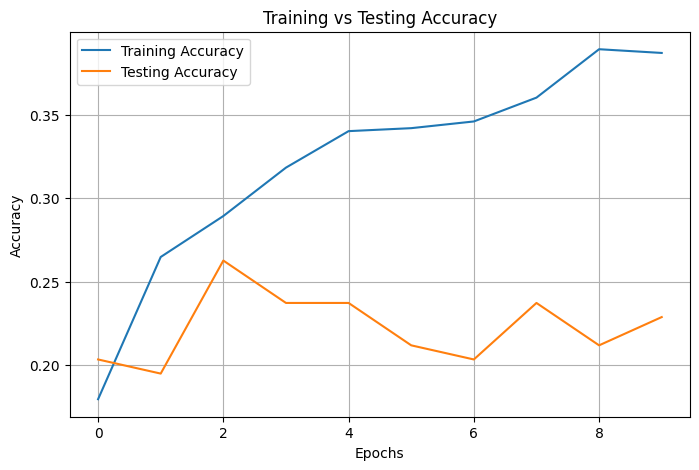

In [10]:
plt.figure(figsize=(8,5))


plt.plot(
    history.history['accuracy'],
    label="Training Accuracy"
)


plt.plot(
    history.history['val_accuracy'],
    label="Testing Accuracy"
)


plt.title("Training vs Testing Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")


plt.legend()

plt.grid()

plt.show()

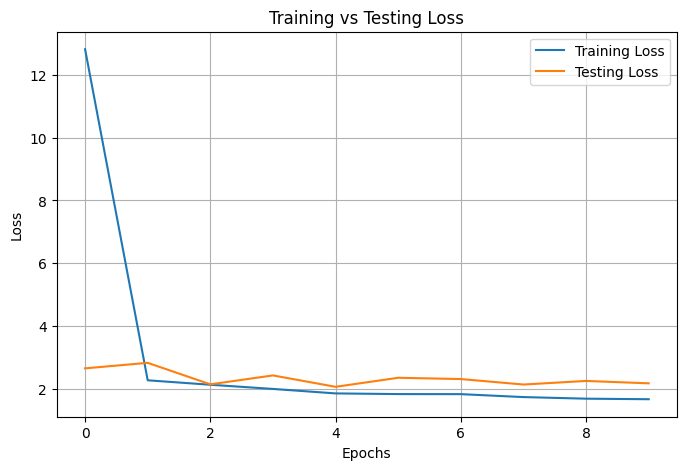

In [11]:
plt.figure(figsize=(8,5))


plt.plot(
    history.history['loss'],
    label="Training Loss"
)


plt.plot(
    history.history['val_loss'],
    label="Testing Loss"
)


plt.title("Training vs Testing Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")


plt.legend()

plt.grid()

plt.show()

In [12]:
y_true = []

y_pred = []

y_prob = []



for images, labels in test_ds:


    predictions = model.predict(images)


    y_true.extend(labels.numpy())


    y_pred.extend(
        np.argmax(predictions, axis=1)
    )


    y_prob.extend(predictions)



y_true = np.array(y_true)

y_pred = np.array(y_pred)

y_prob = np.array(y_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


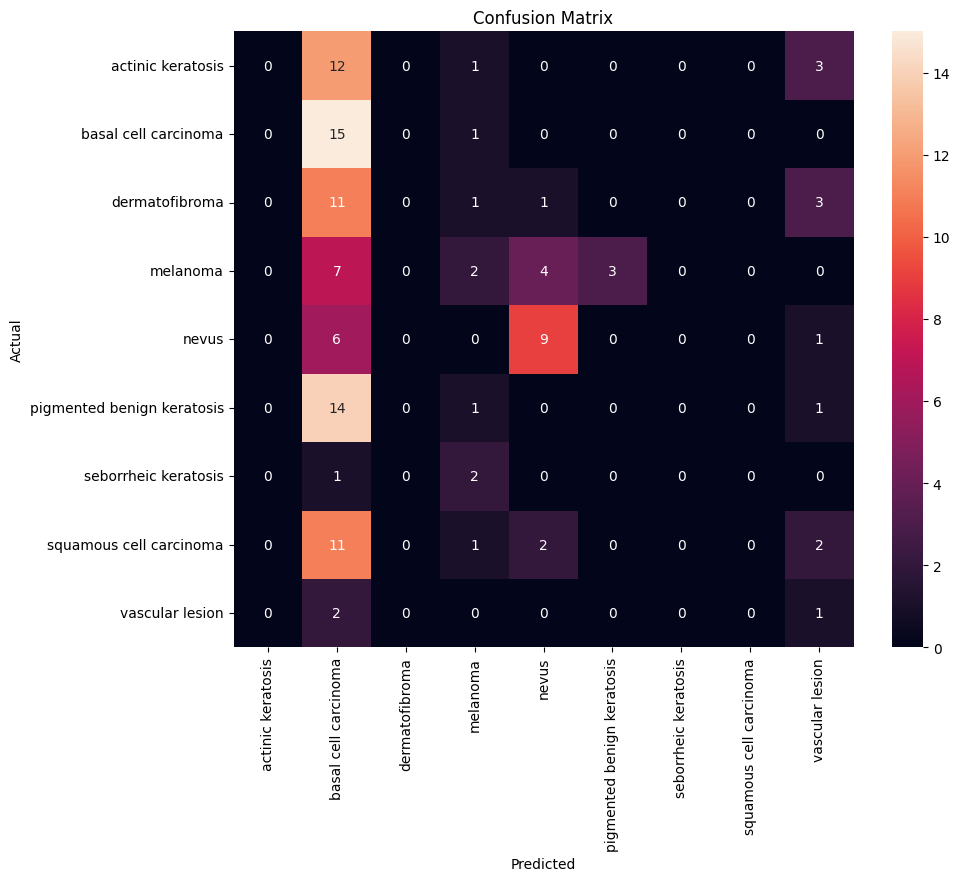

In [13]:
cm = confusion_matrix(
    y_true,
    y_pred
)



plt.figure(figsize=(10,8))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)


plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")


plt.show()


In [14]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.19      0.94      0.32        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.22      0.12      0.16        16
                     nevus       0.56      0.56      0.56        16
pigmented benign keratosis       0.00      0.00      0.00        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       0.09      0.33      0.14         3

                  accuracy                           0.23       118
                 macro avg       0.12      0.22      0.13       118
              weighted avg       0.13      0.23      0.14       118



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)


print("F1 Score =", f1)

F1 Score = 0.1444169746399898


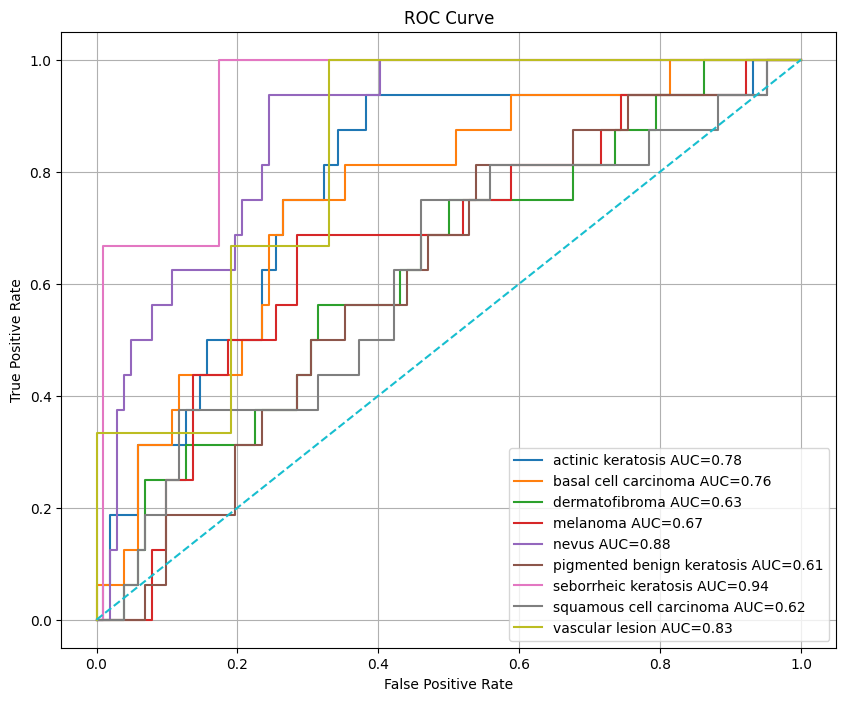

In [16]:
y_true_onehot = tf.keras.utils.to_categorical(
    y_true,
    num_classes=len(class_names)
)



plt.figure(figsize=(10,8))



for i in range(len(class_names)):


    fpr, tpr, _ = roc_curve(

        y_true_onehot[:,i],

        y_prob[:,i]

    )


    roc_auc = auc(
        fpr,
        tpr
    )


    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} AUC={roc_auc:.2f}"
    )



plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)



plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")


plt.legend()

plt.grid()


plt.show()

In [17]:
roc_auc = roc_auc_score(

    y_true_onehot,

    y_prob,

    multi_class="ovr"

)


print("ROC AUC Score =", roc_auc)

ROC AUC Score = 0.7446285639859809


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


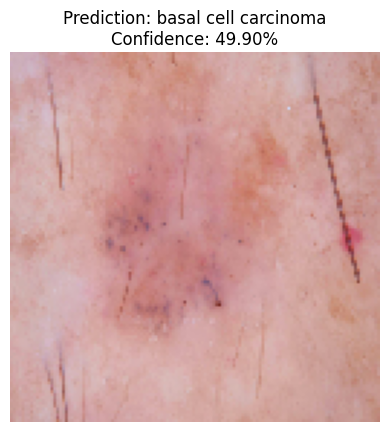

Prediction: basal cell carcinoma
Confidence: 49.90%


In [21]:
# ============================
# Single Image Prediction
# ============================


img_path = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration/Test/basal cell carcinoma/ISIC_0024331.jpg"


img = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=img_size
)



img_array = tf.keras.preprocessing.image.img_to_array(img)


img_array = np.expand_dims(
    img_array,
    axis=0
) / 255.0



prediction = model.predict(img_array)



predicted_index = np.argmax(prediction)


predicted_class = class_names[predicted_index]


confidence = np.max(prediction) * 100



plt.imshow(img)

plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.show()



print("Prediction:", predicted_class)

print("Confidence:", f"{confidence:.2f}%")